<a href="https://colab.research.google.com/github/JenilMP-09/Titanic_Data_Analysis_With_Data_Visualization/blob/main/Titanic_Data_Analysis_With_Data_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Mini Visualization Dashboard (Matplotlib + Seaborn) on Student Performance Dataset:

* In Task-3, you performed a deeper EDA on the Titanic dataset (cleaning, grouping, and basic visualizations).
* Now you will create a mini data visualization dashboard inside a single jupyter notebook.
* Your goal is to communicate key insights with well-chosen charts and short, clear interpretations beneath each figure.
* You have to use "Titanic" dataset. Focus on: data cleaning, feature engineering (simple), multiple plot types, and concise insights.

In [90]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()   # For seaborn styling

### 1. Data Preparation:

    * Load CSV into pandas.
    * Handle missing values.
    * Create 1-2 helpful features.

In [91]:
# Load the Titanic dataset from Google Drive into a DataFrame:

df = pd.read_csv("/content/drive/MyDrive/Data_Science_Folder/Datasets/titanic_dataset.csv")

In [92]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [93]:
# Display dataset info: column names, non-null counts, and data types
#
# This helps identify which columns have missing (null) values:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [94]:
# Statistical summary of titanic dataset:
#
# Shows count, mean, std, min, percentiles, and max for each numeric column

df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


1. Clean Dataset:

    * Fill missing Age with mean:

In [95]:
# Fill missing values in the 'Age' column with the median age
#
# Using median instead of mean makes the imputation more robust to outliers:

df["Age"] = df["Age"].fillna(df["Age"].median())

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          418 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [97]:
# Fill missing values in the 'Fare' column with the median fare
#
# Using median to avoid skew from extreme fare values:

df["Fare"] = df["Fare"].fillna(df["Fare"].median())

    * Drop irrelevant columns (like Cabin):

In [98]:
# Drop the 'Cabin' column entirely because it has too many missing values
#
# (only ~22% non-null), making it unreliable for analysis

df.drop(columns=["Cabin"], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          418 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         418 non-null    float64
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 36.1+ KB


In [99]:
# Define age bins and labels to categorize passengers into meaningful age groups:

bins = [0, 12, 18, 30, 45, 60, 80]
labels = ["Child (0-12)", "Teen (13-18)", "Young Adult (19-30)", "Adult (31-45)", "Middle-aged (46-60)", "Senior (61-80)"]

# Create a new 'Age_Group' column by binning the 'Age' column using the defined bins
#
# pd.cut assigns each passenger to the appropriate age group label

df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

In [100]:
# Calculate survival rate (%) per age group
#
# observed=True ensures only age groups that appear in the data are shown:

round(df.groupby("Age_Group", observed=True)["Survived"].mean()*100, 2)

,Survived
Age_Group,
Child (0-12),48.00
Teen (13-18),41.38
Young Adult (19-30),33.62
Adult (31-45),35.00
Middle-aged (46-60),43.90
Senior (61-80),36.36


In [101]:
# Calculate family size onboard by adding "SibSp" and "Parch" column's data:

df["FamilySize"] = df["SibSp"] + df["Parch"]

In [102]:
# Calculates survival rate (%) by family size:

round(df.groupby("FamilySize")["Survived"].mean() * 100, 2)

,Survived
FamilySize,
0,26.88
1,48.65
2,52.63
3,71.43
4,28.57
5,66.67
6,25.00
7,50.00
10,50.00


### 2. Dashboard Plots (>= 5 distinct charts)

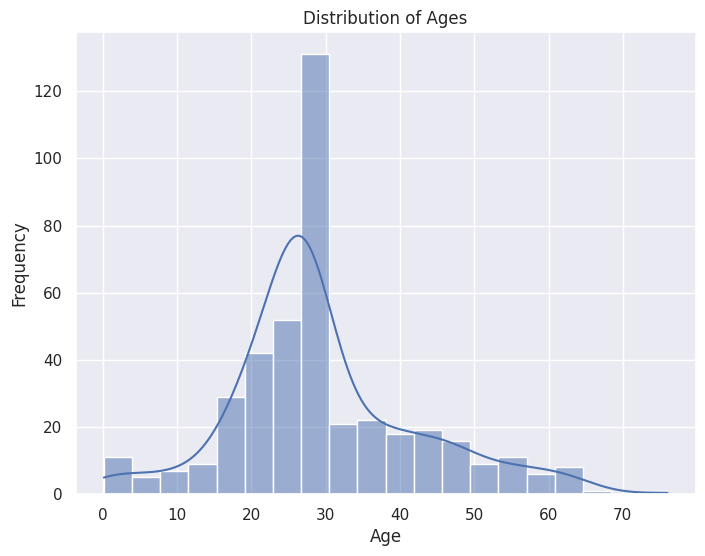

In [103]:
# A histogram showing the distribution of ages:

plt.figure(figsize=(8, 6))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Distribution of Ages")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

* **Insight:** This histogram divides the age range into 20 equal-width bins and counts how many students fall into each.

/tmp/ipykernel_3096/3405712702.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Survived", y="Fare", data=df, palette="coolwarm")


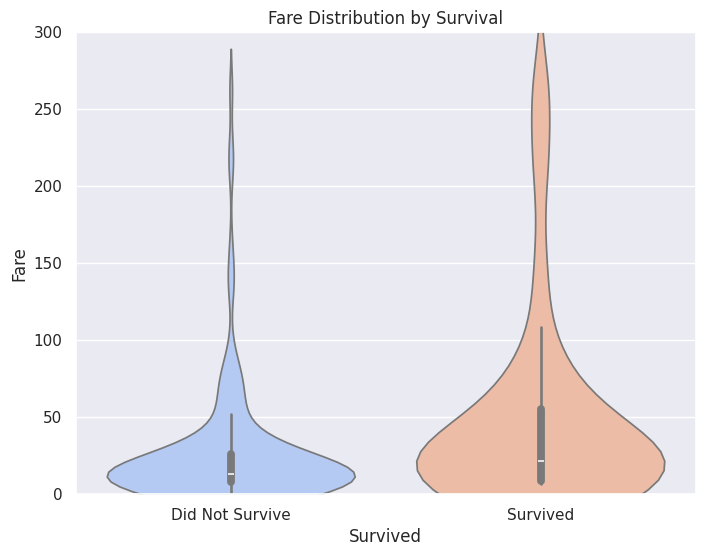

In [104]:
# Fare distribution by Survival (Violin Plot):

plt.figure(figsize=(8, 6))
sns.violinplot(x="Survived", y="Fare", data=df, palette="coolwarm")
plt.title("Fare Distribution by Survival")
plt.xticks([0, 1], ["Did Not Survive", "Survived"])
plt.ylim(0, 300)
plt.show()

* **Insight:** This plot combines a boxplot and KDE curve. Survivors had a much wider and higher fare distribution.

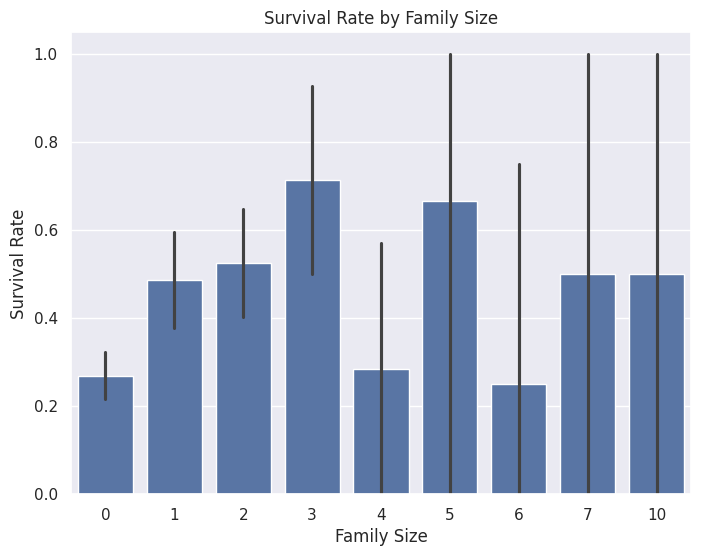

In [105]:
# Bar chart showing survival rate by family size:

plt.figure(figsize=(8, 6))
sns.barplot(x="FamilySize", y="Survived", data=df)
plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")
plt.show()

* **Insight:** This bar chart represents the survival rate for each family size group.

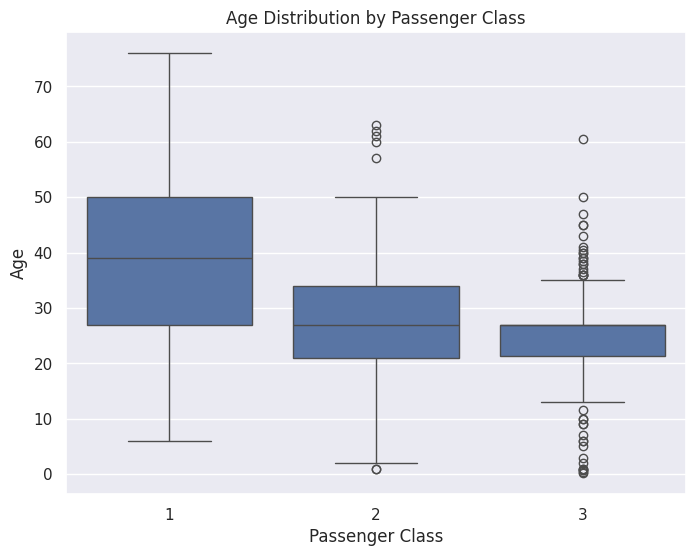

In [106]:
# Boxplot to show distribution and outliers:

plt.figure(figsize=(8, 6))
sns.boxplot(x="Pclass", y="Age", data=df)
plt.title("Age Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Age")
plt.show()

* **Insight:** Here, Each box represents the age distribution of passengers within that ticket class. So, these are the three side-by-side boxplots for Pclass 1, 2, and 3.

/tmp/ipykernel_3096/1098611964.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Embarked", y="Survived", data=df, palette="muted")


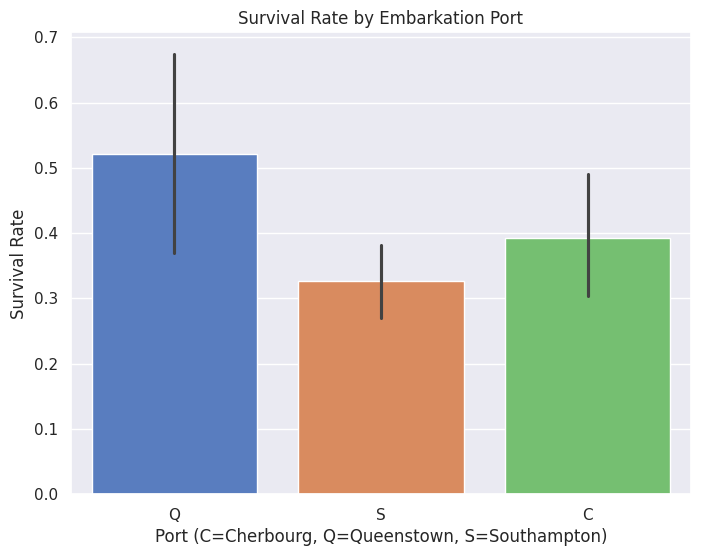

In [107]:
# Embarkation Port vs Survival Rate:

plt.figure(figsize=(8, 6))
sns.barplot(x="Embarked", y="Survived", data=df, palette="muted")
plt.title("Survival Rate by Embarkation Port")
plt.xlabel("Port (C=Cherbourg, Q=Queenstown, S=Southampton)")
plt.ylabel("Survival Rate")
plt.show()

* **Insight:** Passengers who boarded at "Cherbourg(C)" had the highest survival rate (~55%), largely because more 1st class passengers embarked there.

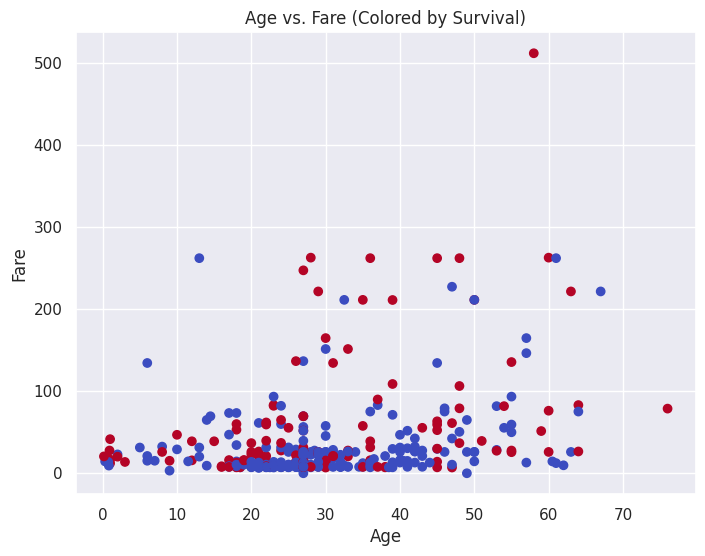

In [108]:
# Scatterplot for relationship (Age vs. Fare colored by Survival):

plt.figure(figsize=(8, 6))
plt.scatter(x="Age", y="Fare", c="Survived", cmap="coolwarm", data=df)
plt.title("Age vs. Fare (Colored by Survival)")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

* **Insight:** In this scatter plot, each dot is one passenger. The axes encode two continuous variables, and the color encodes survival via "coolwarm" colormap.

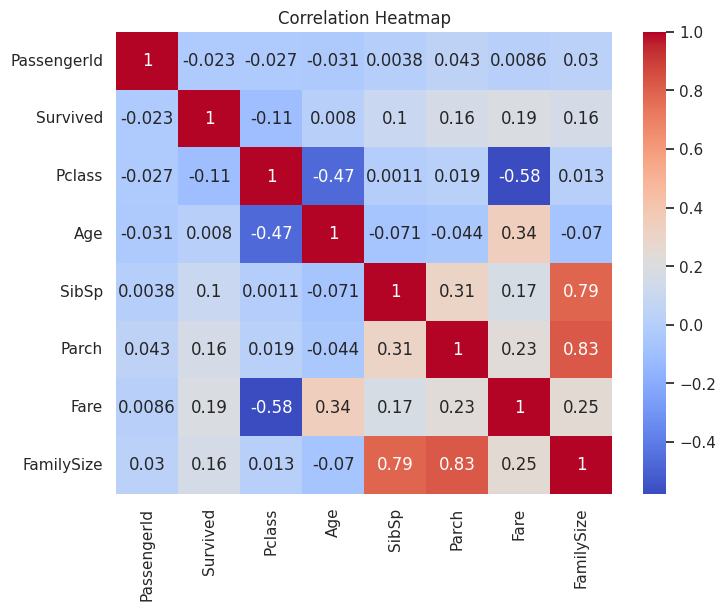

In [109]:
# A heatmap showing the correlations of all numerical data:

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

* **Insight:** Here, **df.corr()** computes the "Pearson correlation coefficient" between every pair of numerica columns. The result is a square matrix where each cell shows how strongly two variables move together.

* The heatmap colors that matrix:
  * Deep Red --> Strong positive correlation (+1)
  * White / Pale --> No correlation (0)
  * Deep Blue --> Strong negative correlation (-1)